## Módulo 1 - Análisis Exploratorio De Datos

### Introducción

In [1]:
# Importamos librerías
import pandas as pd
import matplotlib.pyplot as plt
import os
from pathlib import Path

In [2]:
# Leemos el primer CSV (reviews de hoteles)

# Tomamos la carpeta actual del notebook
# Como el notebook está dentro de Scripts/, subimos un nivel para llegar a la raíz del repo
current_path = Path.cwd()

# Construimos la ruta relativa al archivo dentro del repo
# Esto evita hardcodear rutas locales tipo /Users/... y funciona en cualquier computadora mientras todos mantengamos la misma estructura de carpetas.
ruta_hotel_reviews = current_path.parent / "Data" / "Raw" / "hotel_review.csv"

# Leemos el CSV
df = pd.read_csv(ruta_hotel_reviews)

/var/folders/3_/n3rxgyx52s38d1zrs4t2d3v00000gn/T/ipykernel_16883/3654359266.py:12: DtypeWarning: Columns (26) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(ruta_hotel_reviews)


In [3]:
# Shape
print(f'El DataFrame tiene {df.shape[0]} filas y {df.shape[1]} columnas.')

El DataFrame tiene 405049 filas y 31 columnas.


In [4]:
# Columnas
df.columns

Index(['user_id', 'transaction_id_review', 'hotel_id_review', 'fecha_review',
       'fecha_checkout', 'idioma', 'overall_rating', 'score_ubicacion',
       'score_limpieza', 'score_habitacion', 'score_servicio',
       'score_personal', 'score_banio', 'score_internet', 'score_comida',
       'score_calidad_precio', 'perfil_viajero', 'es_pareja', 'es_familia',
       'es_viaje_negocios', 'es_perfil_lujo', 'es_perfil_economico',
       'es_romantico', 'es_perfil_relax', 'texto_positivo', 'texto_negativo',
       'moderado', 'es_vacation_rental', 'usuario_anonimo',
       'largo_review_chars', 'canal_solicitud_review'],
      dtype='object')

In [5]:
# Chequeamos nulos
df.isnull().sum()

user_id                        0
transaction_id_review          2
hotel_id_review                0
fecha_review                   0
fecha_checkout                 0
idioma                         0
overall_rating                 0
score_ubicacion                0
score_limpieza                 0
score_habitacion               0
score_servicio                 0
score_personal                 0
score_banio                    0
score_internet                 0
score_comida                   0
score_calidad_precio           0
perfil_viajero                 0
es_pareja                      0
es_familia                     0
es_viaje_negocios              0
es_perfil_lujo                 0
es_perfil_economico            0
es_romantico                   0
es_perfil_relax                0
texto_positivo               107
texto_negativo             82786
moderado                  286117
es_vacation_rental             0
usuario_anonimo                0
largo_review_chars             0
canal_soli

In [6]:
# Leemos el segundo CSV (descripciones de hoteles)

# Construimos la ruta relativa al archivo dentro del repo
ruta_hotel_descriptions = Path.cwd().parent / "Data" / "Raw" / "hotel_description.csv"

# Leemos el CSV
df2 = pd.read_csv(ruta_hotel_descriptions)

In [7]:
# Head
df2.head()

,hotel_oid,descripcion_es,descripcion_pt,descripcion_en,descripcion_preferida,idiomas_disponibles,cantidad_idiomas
0,656576,Ashgrove B&B está localizado en Kirkcaldy. Cue...,Ashgrove B&B encontra-se em Kirkcaldy. Conta c...,Ashgrove B&B is situated in Kirkcaldy. Feature...,Ashgrove B&B está localizado en Kirkcaldy. Cue...,"ES, PT, EN",3
1,771876,Hotel & SPA Diamant Residence - All Inclusive ...,Hotel & SPA Diamant Residence - All Inclusive ...,Hotel & SPA Diamant Residence - All Inclusive ...,Hotel & SPA Diamant Residence - All Inclusive ...,"ES, PT, EN",3
2,1320443,Ubicación del establecimiento Si eliges Hotel ...,"Localização do estabelecimento Hotel Nubes, em...",Property Location With a stay at Hotel Nubes i...,Ubicación del establecimiento Si eliges Hotel ...,"ES, PT, EN",3
3,887131,Hôtel Providence se encuentra en París. Cuenta...,Hôtel Providence situa-se em Paris. Conta com ...,Hôtel Providence is located in Paris. Features...,Hôtel Providence se encuentra en París. Cuenta...,"ES, PT, EN",3
4,812895,Full Hotel - Zhuzhou está localizado en Zhuzho...,Full Hotel - Zhuzhou situa-se em Zhuzhou. Disp...,Full Hotel - Zhuzhou is located in Zhuzhou. Fe...,Full Hotel - Zhuzhou está localizado en Zhuzho...,"ES, PT, EN",3


In [8]:
# Leemos el tercer y último CSV (metadata de hoteles)

# Construimos la ruta relativa al archivo dentro del repo
ruta_hotel_metadata = Path.cwd().parent / "Data" / "Raw" / "hotel_metadata.csv"

# Leemos el CSV
df3 = pd.read_csv(ruta_hotel_metadata)

In [9]:
# Head
df3.head()

,hotel_id,name,city,country,country_code,star_rating,hotel_type,latitude,longitude,amenities,meal_plans
0,200006.0,"The Westin Maui Resort & Spa, Ka'anapali",Lahaina,Estados Unidos,US,4.0,Hoteles,20.919841,-156.694854,"{'Señalización en braille o en relieve','Snack...",NaN
1,200008.0,The Mauian - Boutique Beach Studios on Napili Bay,Lahaina,Estados Unidos,US,3.0,Hoteles,20.995463,-156.665207,"{'Mascotas: no se admiten','Máquina expendedor...",NaN
2,200012.0,Country Plaza,Guadalajara,México,MX,3.0,Hoteles,20.713712,-103.384064,"{'Máquina expendedora ','Centro de negocios','...",{'ROOM_ONLY'}
3,200013.0,Kohea Kai Hotel Maui,Kihei,Estados Unidos,US,3.0,Hoteles,20.768898,-156.458630,"{'Caja fuerte en la recepción','Senderismo/cic...",NaN
4,200015.0,Quality Inn & Suites North Lima - Boardman,North Lima,Estados Unidos,US,2.0,Hoteles,40.973910,-80.661430,{'Servicio de guarda-equipaje con costo adicio...,NaN


In [10]:
# Mergeamos ambos DFs
# Primer merge: reviews + df2
merge_dfs = pd.merge(
    df,
    df2,
    left_on = 'hotel_id_review',
    right_on = 'hotel_oid',
    how = 'left'
)

# Segundo merge: sumamos df3
merge_dfs = pd.merge(
    merge_dfs,
    df3,
    left_on ='hotel_id_review',
    right_on = 'hotel_id',
    how = 'left'
)

In [11]:
# Merge Head
merge_dfs.head()

,user_id,transaction_id_review,hotel_id_review,fecha_review,fecha_checkout,idioma,overall_rating,score_ubicacion,score_limpieza,score_habitacion,...,name,city,country,country_code,star_rating,hotel_type,latitude,longitude,amenities,meal_plans
0,54ce31dbe4b0fc82d14e279e,"28,730,481,402",4669631,"10 febrero, 2025","31 enero, 2025",ES,95.56,100,100,100,...,Buona Vitta Gramado Resort & Spa by Gramado Parks,Gramado,Brasil,BR,5.0,Hoteles,-29.366383,-50.858025,"{'Gimnasio','Valet parking','Servicio de spa',...",{'CONTINENTAL_BREAKFAST'}
1,027241d5-88a2-4f03-a1f9-65c0d3fbf2f8,"28,516,833,502",231021,"10 febrero, 2025","6 febrero, 2025",ES,100.00,100,100,100,...,Majestic Rio Palace Hotel,Rio De Janeiro,Brasil,BR,3.0,Hoteles,-22.971061,-43.190216,{'Baño adaptado para personas con movilidad re...,{'BUFFET_BREAKFAST'}
2,454bda73-df1e-4831-8e11-b23e5b84af97,"29,724,690,002",265830,"10 febrero, 2025","4 febrero, 2025",ES,100.00,100,100,100,...,Melia Casa Maya Cancun All Inclusive,Cancún,México,MX,4.0,Hoteles,21.144825,-86.779266,"{'Terraza','Periodo de desinfección entre esta...",{'ALL_INCLUSIVE'}
3,52d0937ae4b07e376002de17,"30,349,430,302",358839,"10 febrero, 2025","9 febrero, 2025",ES,91.11,80,100,100,...,Gran Hotel Continental,Mar Del Plata,Argentina,AR,3.0,Hoteles,-38.001378,-57.548558,"{'Sala de reuniones','Bar','Servicio de conser...",{'BUFFET_BREAKFAST'}
4,58816d68e4b01f548871dbc1,"28,866,842,402",999361,"10 febrero, 2025","10 febrero, 2025",ES,82.22,100,100,60,...,Ibis Budget Rio de Janeiro - Praia de Botafogo,Rio De Janeiro,Brasil,BR,2.0,Hoteles,-22.945135,-43.183727,"{'Recepción 24 hrs','Seguridad 24 hrs','Restau...","{'BREAKFAST','BUFFET_BREAKFAST','ROOM_ONLY'}"


In [12]:
# Columnas
merge_dfs.columns

Index(['user_id', 'transaction_id_review', 'hotel_id_review', 'fecha_review',
       'fecha_checkout', 'idioma', 'overall_rating', 'score_ubicacion',
       'score_limpieza', 'score_habitacion', 'score_servicio',
       'score_personal', 'score_banio', 'score_internet', 'score_comida',
       'score_calidad_precio', 'perfil_viajero', 'es_pareja', 'es_familia',
       'es_viaje_negocios', 'es_perfil_lujo', 'es_perfil_economico',
       'es_romantico', 'es_perfil_relax', 'texto_positivo', 'texto_negativo',
       'moderado', 'es_vacation_rental', 'usuario_anonimo',
       'largo_review_chars', 'canal_solicitud_review', 'hotel_oid',
       'descripcion_es', 'descripcion_pt', 'descripcion_en',
       'descripcion_preferida', 'idiomas_disponibles', 'cantidad_idiomas',
       'hotel_id', 'name', 'city', 'country', 'country_code', 'star_rating',
       'hotel_type', 'latitude', 'longitude', 'amenities', 'meal_plans'],
      dtype='object')

### Armado Del Dataset

In [13]:
# Armamos una copia del DF mergeado para trabajar en el DF final
df_work = merge_dfs.copy()

In [14]:
# Info
df_work.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 405049 entries, 0 to 405048
Data columns (total 49 columns):
 #   Column                  Non-Null Count   Dtype  
---  ------                  --------------   -----  
 0   user_id                 405049 non-null  object 
 1   transaction_id_review   405047 non-null  object 
 2   hotel_id_review         405049 non-null  int64  
 3   fecha_review            405049 non-null  object 
 4   fecha_checkout          405049 non-null  object 
 5   idioma                  405049 non-null  object 
 6   overall_rating          405049 non-null  float64
 7   score_ubicacion         405049 non-null  int64  
 8   score_limpieza          405049 non-null  int64  
 9   score_habitacion        405049 non-null  int64  
 10  score_servicio          405049 non-null  int64  
 11  score_personal          405049 non-null  int64  
 12  score_banio             405049 non-null  int64  
 13  score_internet          405049 non-null  int64  
 14  score_comida        

In [15]:
# Describe traspuesta (incluyendo categóricas)
df_work.describe(include = 'all').T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
user_id,405049,342982,bdf9073e-fcc3-471c-b5c9-52b13438acde,30,NaN,NaN,NaN,NaN,NaN,NaN,NaN
transaction_id_review,405047,405043,"34,971,597",5,NaN,NaN,NaN,NaN,NaN,NaN,NaN
hotel_id_review,405049.0,NaN,NaN,NaN,1427682.645998,1878738.397851,200002.0,301957.0,378632.0,1585747.0,7091578.0
fecha_review,405049,483,"5 enero, 2026",1803,NaN,NaN,NaN,NaN,NaN,NaN,NaN
fecha_checkout,405049,537,"22 junio, 2025",1917,NaN,NaN,NaN,NaN,NaN,NaN,NaN
idioma,405049,3,ES,251961,NaN,NaN,NaN,NaN,NaN,NaN,NaN
overall_rating,405049.0,NaN,NaN,NaN,83.722863,16.824978,20.0,75.56,88.89,97.78,100.0
score_ubicacion,405049.0,NaN,NaN,NaN,89.81659,16.298945,20.0,80.0,100.0,100.0,100.0
score_limpieza,405049.0,NaN,NaN,NaN,85.02991,21.106507,20.0,80.0,100.0,100.0,100.0
score_habitacion,405049.0,NaN,NaN,NaN,82.083205,21.655375,20.0,80.0,80.0,100.0,100.0


Comenzamos dropeando algunas columnas que entendemos no nos serán útiles para el armado de la solución.

In [16]:
cols_to_drop = [
    'user_id', # El sistema no personaliza para cada usuario, sino que lo hace en función del prompt del usuario al agente final
    'transaction_id_review', # No aporta para NLP/recomendación
    'hotel_oid', # Se duplica después del merge porque ya tenemos hotel_id_review
    'hotel_id', # Se duplica después del merge porque ya tenemos hotel_id_review
    'es_vacation_rental', # Columna constante = 1, no agrega señal
    'usuario_anonimo', # Columna constante = 1, no agrega señal
    'canal_solicitud_review', # No sirve para el sistema que estamos pensando
    'descripcion_es', # Nos quedamos con descripcion_preferida, en ppio no vamos a conectar descripción con review por lo que estaríamos OK con este drop
    'descripcion_pt', # Nos quedamos con descripcion_preferida, en ppio no vamos a conectar descripción con review por lo que estaríamos OK con este drop
    'descripcion_en', # Nos quedamos con descripcion_preferida, en ppio no vamos a conectar descripción con review por lo que estaríamos OK con este drop
    'cantidad_idiomas', # Metadata sobre disponibilidad de descripciones, no aporta contenido semántico directo
    'idiomas_disponibles', # Metadata sobre idiomas disponibles, redundante si usamos descripcion_preferida
    'latitude', # Metadata sobre latitud de ubicación, no aporta al objetivo del sistema
    'longitude', # Metadata sobre longitud de ubicación, no aporta al objetivo del sistema
    'country_code', # No aporta al objetivo del sistema
]

In [17]:
# Drop
df_work.drop(columns = cols_to_drop, inplace = True)
df_work.head()

,hotel_id_review,fecha_review,fecha_checkout,idioma,overall_rating,score_ubicacion,score_limpieza,score_habitacion,score_servicio,score_personal,...,moderado,largo_review_chars,descripcion_preferida,name,city,country,star_rating,hotel_type,amenities,meal_plans
0,4669631,"10 febrero, 2025","31 enero, 2025",ES,95.56,100,100,100,100,100,...,NaN,54,Buona Vitta Gramado Resort & Spa by Gramado Pa...,Buona Vitta Gramado Resort & Spa by Gramado Parks,Gramado,Brasil,5.0,Hoteles,"{'Gimnasio','Valet parking','Servicio de spa',...",{'CONTINENTAL_BREAKFAST'}
1,231021,"10 febrero, 2025","6 febrero, 2025",ES,100.00,100,100,100,100,100,...,NaN,330,Situado a tres cuadras de la Playa de Copacaba...,Majestic Rio Palace Hotel,Rio De Janeiro,Brasil,3.0,Hoteles,{'Baño adaptado para personas con movilidad re...,{'BUFFET_BREAKFAST'}
2,265830,"10 febrero, 2025","4 febrero, 2025",ES,100.00,100,100,100,100,100,...,NaN,49,Melia Casa Maya Cancun All Inclusive se encuen...,Melia Casa Maya Cancun All Inclusive,Cancún,México,4.0,Hoteles,"{'Terraza','Periodo de desinfección entre esta...",{'ALL_INCLUSIVE'}
3,358839,"10 febrero, 2025","9 febrero, 2025",ES,91.11,80,100,100,100,100,...,NaN,71,"Situado a 250 m de la peatonal de San Martín, ...",Gran Hotel Continental,Mar Del Plata,Argentina,3.0,Hoteles,"{'Sala de reuniones','Bar','Servicio de conser...",{'BUFFET_BREAKFAST'}
4,999361,"10 febrero, 2025","10 febrero, 2025",ES,82.22,100,100,60,100,100,...,NaN,12,NaN,Ibis Budget Rio de Janeiro - Praia de Botafogo,Rio De Janeiro,Brasil,2.0,Hoteles,"{'Recepción 24 hrs','Seguridad 24 hrs','Restau...","{'BREAKFAST','BUFFET_BREAKFAST','ROOM_ONLY'}"


#### **Idioma**

En primer lugar, hacemos un análisis descriptivo/gráfico sobre la distribución del idioma de las reviews.

In [18]:
# Calculamos la cantidad de reviews por idioma
reviews_por_idioma = (df_work
                     .groupby('idioma')
                     .agg(count_reviews = ('fecha_review', 'count'))
                     .sort_values('count_reviews', ascending = False)
                     .reset_index())
reviews_por_idioma

,idioma,count_reviews
0,ES,251961
1,PT,152799
2,EN,289


In [19]:
# Sumamos el % que representa cada una del total
reviews_por_idioma['pct_reviews'] = (reviews_por_idioma['count_reviews'] / reviews_por_idioma['count_reviews'].sum() * 100)
reviews_por_idioma

,idioma,count_reviews,pct_reviews
0,ES,251961,62.205067
1,PT,152799,37.723584
2,EN,289,0.071349


Las reviews en idioma inglés representan apenas el 0,07% del dataset total, por lo que decidimos excluirlas del análisis. Esta decisión no responde a una limitación del modelo para procesar inglés, sino a un criterio de alcance y representatividad: con tan pocos casos, el inglés no aporta una señal relevante para el sistema de recomendación y, al mismo tiempo, agrega complejidad innecesaria al pipeline.

Al trabajar exclusivamente con español y portugués, que concentran el 99,93% de las reviews, podemos enfocar el procesamiento, la extracción de atributos, la validación de resultados y la evaluación del recomendador en los idiomas donde realmente existe volumen suficiente de datos. De esta forma, el sistema se mantiene más consistente, más fácil de validar y mejor alineado con la distribución real del dataset.

In [20]:
# Armamos la máscara para quedarnos con las filas que queremos
mask_idioma = df_work['idioma'] != 'EN'

# Filramos el DataFrame
df_work = df_work.loc[mask_idioma, :].reset_index(drop = True)

# Chequeamos
df_work['idioma'].unique()

array(['ES', 'PT'], dtype=object)

#### **Calidad De Reviews**

Ahora bien, el corazón de nuestra solución se basa en las reviews (texto_positivo y texto_negativo). A priori, consideramos importante entender cuántas reviews tienen al menos uno de los dos textos.

In [21]:
# Planteamos algunas métricas en relación a los textos positivos y negativos de las reviews
total = len(df_work)
con_pos = df_work['texto_positivo'].notna().sum()
con_neg = df_work['texto_negativo'].notna().sum()
con_ambos = (df_work['texto_positivo'].notna() & df_work['texto_negativo'].notna()).sum()
solo_pos = (df_work['texto_positivo'].notna() & df_work['texto_negativo'].isna()).sum()
solo_neg = (df_work['texto_positivo'].isna() & df_work['texto_negativo'].notna()).sum()
sin_texto = (df_work['texto_positivo'].isna() & df_work['texto_negativo'].isna()).sum()

print(f'Total de reviews: {total:,}')
print(f'Con texto positivo: {con_pos:,} ({con_pos / total * 100:.2f}%)')
print(f'Con texto negativo: {con_neg:,} ({con_neg / total * 100:.2f}%)')
print(f'Con ambos textos: {con_ambos:,} ({con_ambos/total * 100:.2f}%)')
print(f'Solo positivo: {solo_pos:,} ({solo_pos / total * 100:.2f}%)')
print(f'Solo negativo: {solo_neg:,} ({solo_neg / total * 100:.2f}%)')
print(f'Sin ningún texto: {sin_texto:,} ({sin_texto / total * 100:.2f}%)')

Total de reviews: 404,760
Con texto positivo: 404,653 (99.97%)
Con texto negativo: 322,058 (79.57%)
Con ambos textos: 322,029 (79.56%)
Solo positivo: 82,624 (20.41%)
Solo negativo: 29 (0.01%)
Sin ningún texto: 78 (0.02%)


El análisis muestra que el texto positivo está disponible en prácticamente todas las reviews (99.97%), mientras que el texto negativo aparece en el 80% de los casos. Esto es esperable: muchos usuarios escriben solo aspectos positivos cuando están conformes con su estadía.

Identificamos también 78 reviews que no contienen ningún texto, las cuales descartamos por no aportar señal alguna al pipeline de NLP. Mantenemos en cambio las reviews con al menos uno de los dos textos disponibles, asumiendo que el pipeline de extracción de atributos e ideas principales debe contemplar la posibilidad de que el texto negativo sea nulo.

In [22]:
# Descartamos reviews que no tienen ni texto positivo ni negativo
mask_con_texto = df_work['texto_positivo'].notna() | df_work['texto_negativo'].notna() # Máscara de filas con al menos un texto

df_work = df_work[mask_con_texto].reset_index(drop = True) # Filtro

print(f'Reviews después del filtro: {df_work.shape[0]:,}')

Reviews después del filtro: 404,682


En esta misma línea, consideramos importante el contenido de las reviews. No solo es importante que la review exista, sino también que sea rica para que el pipeline de NLP pueda extraer información útil. Reviews como "Nada" cumplen con tener texto pero no aportan señal.

In [23]:
# Calculamos el largo de los textos
df_work['len_positivo'] = df_work['texto_positivo'].fillna('').str.len()
df_work['len_negativo'] = df_work['texto_negativo'].fillna('').str.len()

# Distribución
print('Texto positivo:')
print(df_work['len_positivo'].describe().round(1))
print('\nTexto negativo:')
print(df_work['len_negativo'].describe().round(1))

Texto positivo:
count    404682.0
mean         71.2
std          99.4
min           0.0
25%          19.0
50%          40.0
75%          84.0
max        1416.0
Name: len_positivo, dtype: float64

Texto negativo:
count    404682.0
mean         85.4
std         143.1
min           0.0
25%           4.0
50%          36.0
75%         102.0
max        1412.0
Name: len_negativo, dtype: float64


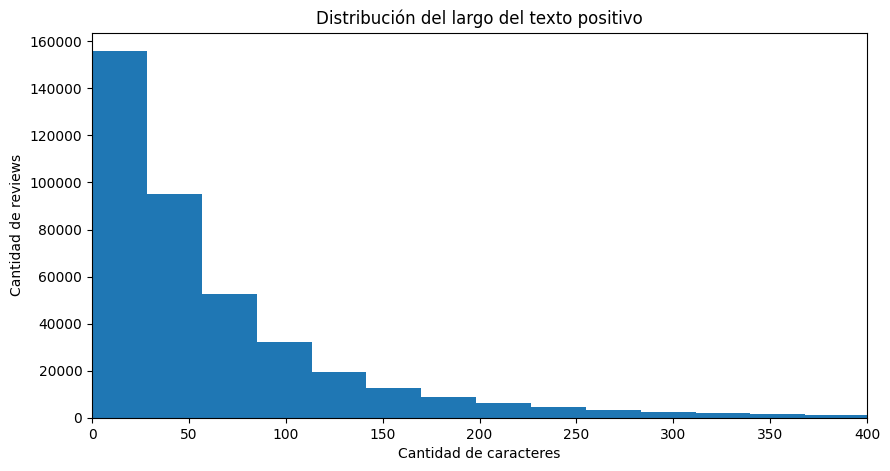

In [24]:
# Graficamos el largo del texto positivo
plt.figure(figsize = (10, 5)) # Lienzo
plt.hist(df_work['len_positivo'], bins = 50) # Gráfico

# Formato
plt.title('Distribución del largo del texto positivo')
plt.xlabel('Cantidad de caracteres')
plt.ylabel('Cantidad de reviews')
plt.xlim(0, 400) # Cola izquierda de interés

plt.show()

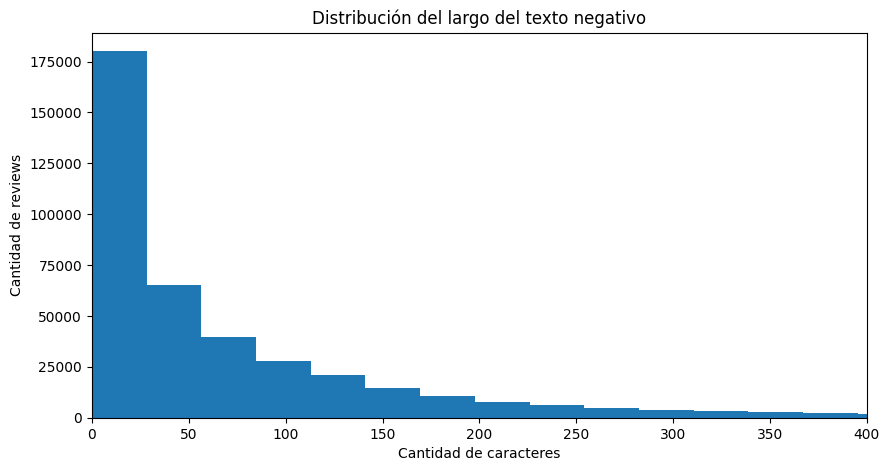

In [25]:
# Graficamos el largo del texto negativo
plt.figure(figsize = (10, 5)) # Lienzo
plt.hist(df_work['len_negativo'], bins = 50) # Plot

# Formato
plt.title('Distribución del largo del texto negativo')
plt.xlabel('Cantidad de caracteres')
plt.ylabel('Cantidad de reviews')
plt.xlim(0, 400) # Cola izquierda de interés

plt.show()

Notamos que el mínimo de las reviews es de 0 caracteres. En el caso del texto negativo esto es esperable, ya que rellenamos los nulos con string vacío al calcular el largo. En el caso del texto positivo, en cambio, indica que hay reviews donde el campo viene vacío directamente. Más allá de los strings vacíos, también identificamos previamente que existen reviews compuestas únicamente por tokens no informativos ("Nada", "Todo", ".", "-", entre otros), que cumplen formalmente con tener texto pero no aportan señal alguna al pipeline de NLP.


Por eso, armamos una lista 'defensiva' de tokens basura y descartamos únicamente aquellas reviews donde ambos campos (positivo y negativo) son no informativos. Mantenemos en cambio las reviews donde al menos uno de los dos campos contiene una mención útil, aunque sea breve (como "Ubicación" o "Desayuno"), ya que estas menciones cortas son votos directos a atributos del hotel y constituyen señal valiosa para los dos primeros módulos del sistema (extracción tabular de atributos y generación de vectores semánticos a partir de ideas principales).

In [26]:
# Lista de tokens no informativos en español y portugués
basura = {
    '', ' ', '.', '..', '...', '-', '_', '*', '/',
    'nada', 'nada.', 'nada!', 'nada,',
    'na', 'n/a', 'no', 'nao',
    'todo', 'tudo', 'todo bien', 'tudo bem', 'todo bom',
    'ok', 'bom', 'bueno', 'buena', 'bien'
}

# Normalizamos los textos para comparar (minúsculas + sin espacios al borde)
pos_norm = df_work['texto_positivo'].fillna('').str.strip().str.lower()
neg_norm = df_work['texto_negativo'].fillna('').str.strip().str.lower()

# Una review se descarta solo si AMBOS textos son basura
mask_descarte = pos_norm.isin(basura) & neg_norm.isin(basura)

print(f'Reviews a descartar: {mask_descarte.sum():,}')
print(f'\nEjemplos de reviews que se descartan:')
df_work.loc[mask_descarte, ['texto_positivo', 'texto_negativo']].head(10)

Reviews a descartar: 6,770

Ejemplos de reviews que se descartan:


,texto_positivo,texto_negativo
10,.,.
67,Todo,Nada
162,Tudo,NaN
186,.,.
311,Todo,Nada
419,Todo,NaN
463,.,.
702,Tudo,Nada
722,Todo,Nada
725,Todo,Nada


In [27]:
# Máscara booleana de descarte
df_work = df_work.loc[mask_descarte == False].reset_index(drop = True)
print(f'DataFrame actual: {df_work.shape[0]:,} filas')

DataFrame actual: 397,912 filas


In [28]:
# Head final
df_work.head()

,hotel_id_review,fecha_review,fecha_checkout,idioma,overall_rating,score_ubicacion,score_limpieza,score_habitacion,score_servicio,score_personal,...,descripcion_preferida,name,city,country,star_rating,hotel_type,amenities,meal_plans,len_positivo,len_negativo
0,4669631,"10 febrero, 2025","31 enero, 2025",ES,95.56,100,100,100,100,100,...,Buona Vitta Gramado Resort & Spa by Gramado Pa...,Buona Vitta Gramado Resort & Spa by Gramado Parks,Gramado,Brasil,5.0,Hoteles,"{'Gimnasio','Valet parking','Servicio de spa',...",{'CONTINENTAL_BREAKFAST'},54,0
1,231021,"10 febrero, 2025","6 febrero, 2025",ES,100.00,100,100,100,100,100,...,Situado a tres cuadras de la Playa de Copacaba...,Majestic Rio Palace Hotel,Rio De Janeiro,Brasil,3.0,Hoteles,{'Baño adaptado para personas con movilidad re...,{'BUFFET_BREAKFAST'},330,0
2,265830,"10 febrero, 2025","4 febrero, 2025",ES,100.00,100,100,100,100,100,...,Melia Casa Maya Cancun All Inclusive se encuen...,Melia Casa Maya Cancun All Inclusive,Cancún,México,4.0,Hoteles,"{'Terraza','Periodo de desinfección entre esta...",{'ALL_INCLUSIVE'},49,0
3,358839,"10 febrero, 2025","9 febrero, 2025",ES,91.11,80,100,100,100,100,...,"Situado a 250 m de la peatonal de San Martín, ...",Gran Hotel Continental,Mar Del Plata,Argentina,3.0,Hoteles,"{'Sala de reuniones','Bar','Servicio de conser...",{'BUFFET_BREAKFAST'},71,49
4,999361,"10 febrero, 2025","10 febrero, 2025",ES,82.22,100,100,60,100,100,...,NaN,Ibis Budget Rio de Janeiro - Praia de Botafogo,Rio De Janeiro,Brasil,2.0,Hoteles,"{'Recepción 24 hrs','Seguridad 24 hrs','Restau...","{'BREAKFAST','BUFFET_BREAKFAST','ROOM_ONLY'}",12,7


#### **Cantidad De Reviews Por Hotel**

A continuación hacemos un análisis descriptivo/gráfico sobre la distribución de reviews por hotel.

In [29]:
# Calculamos la cantidad de reviews por hotel
reviews_por_hotel = (df_work
                     .groupby('hotel_id_review')
                     .agg(count_reviews = ('fecha_review', 'count'))
                     .sort_values('count_reviews', ascending = False)
                     .reset_index())
reviews_por_hotel

,hotel_id_review,count_reviews
0,378632,1647
1,855163,1212
2,285432,1168
3,231158,1139
4,224586,968
...,...,...
35938,1790177,1
35939,1790054,1
35940,1789985,1
35941,1789621,1


In [30]:
# Métricas descriptivas básicas
print(f"Cantidad de hoteles únicos: {reviews_por_hotel.shape[0]:,}")
print(f"Mediana de reviews por hotel: {reviews_por_hotel['count_reviews'].median():.0f}")
print(f"Promedio de reviews por hotel: {reviews_por_hotel['count_reviews'].mean():.2f}")
print(f"Máximo de reviews para un hotel: {reviews_por_hotel['count_reviews'].max():,}")

Cantidad de hoteles únicos: 35,943
Mediana de reviews por hotel: 2
Promedio de reviews por hotel: 11.07
Máximo de reviews para un hotel: 1,647


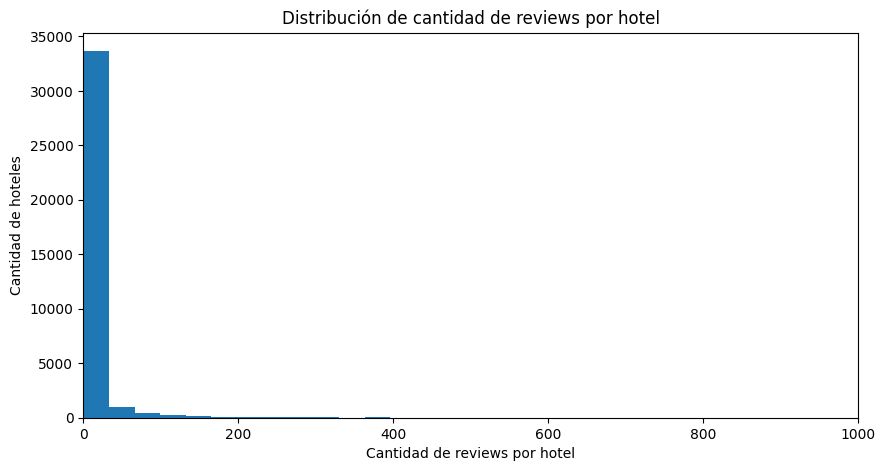

In [31]:
# Graficamos la distribución de reviews por hotel
plt.figure(figsize = (10, 5)) # Lienzo
plt.hist(reviews_por_hotel['count_reviews'], bins = 50) # Plot

# Formato
plt.title('Distribución de cantidad de reviews por hotel') # Título
plt.xlabel('Cantidad de reviews por hotel') # Label X
plt.ylabel('Cantidad de hoteles') # Label Y

plt.xlim(0, 1000)

plt.show()

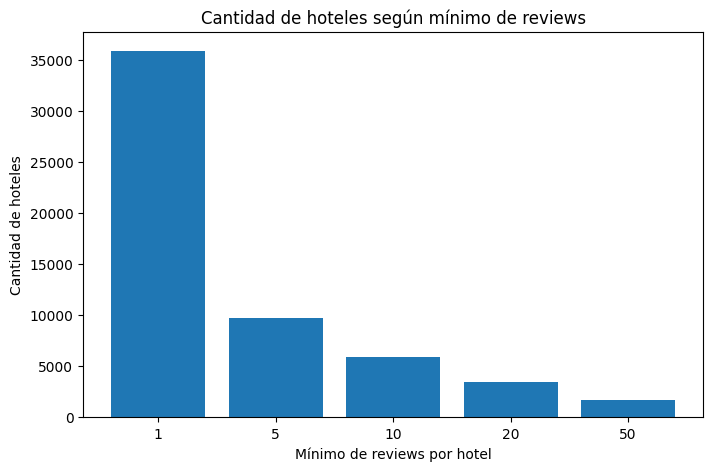

In [32]:
# Graficamos la cantidad de hoteles según umbrales mínimos de reviews
umbrales = [1, 5, 10, 20, 50]

# Sumamos cantidad de hoteles por cada umbral (ciclo)
hoteles_por_umbral = [
    (reviews_por_hotel['count_reviews'] >= umbral).sum()
    for umbral in umbrales
]

plt.figure(figsize = (8, 5)) # Lienzo
plt.bar([str(u) for u in umbrales], hoteles_por_umbral) # Plot

# Formato
plt.title('Cantidad de hoteles según mínimo de reviews')
plt.xlabel('Mínimo de reviews por hotel')
plt.ylabel('Cantidad de hoteles')

plt.show()

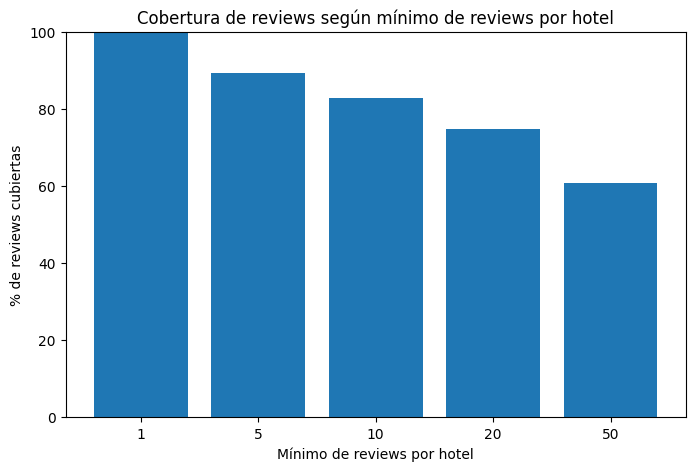

In [33]:
# Graficamos el share de review cubiertas en función de los umbrales definidos
reviews_totales = reviews_por_hotel['count_reviews'].sum()

cobertura_por_umbral = [reviews_por_hotel.loc[reviews_por_hotel['count_reviews'] >= umbral, 'count_reviews'].sum() / reviews_totales * 100 for umbral in umbrales]

plt.figure(figsize = (8, 5)) # Lienzo
plt.bar([str(u) for u in umbrales], cobertura_por_umbral) # Plot

# Formato
plt.title('Cobertura de reviews según mínimo de reviews por hotel')
plt.xlabel('Mínimo de reviews por hotel')
plt.ylabel('% de reviews cubiertas')

plt.ylim(0, 100)

plt.show()

A partir del análisis de reviews por hotel, observamos que la distribución está fuertemente desbalanceada. Si bien el dataset contiene una gran cantidad de hoteles únicos, la mediana de reviews por hotel es baja, lo que indica que muchos hoteles cuentan con muy poca evidencia textual disponible.

Para el objetivo de este trabajo, esto es relevante porque el sistema busca construir recomendaciones a partir de patrones presentes en las reviews. Cuando un hotel tiene muy pocas reviews, las señales extraídas pueden ser débiles, poco representativas o demasiado dependientes de opiniones aisladas.

Por este motivo, decidimos conservar únicamente hoteles con al menos 20 reviews. Este umbral permite reducir ruido y trabajar con hoteles que tienen una base mínima de información textual, sin perder una proporción significativa del dataset (nos quedamos con el 75%). Según el análisis de cobertura, los hoteles que cumplen este criterio concentran una parte mayoritaria de las reviews disponibles, por lo que el recorte mejora la calidad del dataset sin comprometer demasiado el volumen de datos.

En síntesis, el filtro de 20 reviews busca equilibrar dos objetivos: mantener suficiente cantidad de datos para el modelado y asegurar que cada hotel tenga un mínimo de evidencia textual para extraer atributos, ideas principales y representaciones semánticas de manera más confiable.

In [34]:
# Armamos la lista de hoteles que cumplen el umbral
hoteles_validos = reviews_por_hotel.loc[reviews_por_hotel['count_reviews'] >= 20, 'hotel_id_review']

# Filtramos el DF (en una variable nueva primero, para no pisar df_work si algo falla)
df_work = df_work[df_work['hotel_id_review'].isin(hoteles_validos)].reset_index(drop = True)

# Chequeamos que esté ok
print(f'Filas: {df_work.shape[0]:,} | Hoteles únicos: {df_work["hotel_id_review"].nunique():,}')
df_work.head()

Filas: 298,185 | Hoteles únicos: 3,478


,hotel_id_review,fecha_review,fecha_checkout,idioma,overall_rating,score_ubicacion,score_limpieza,score_habitacion,score_servicio,score_personal,...,descripcion_preferida,name,city,country,star_rating,hotel_type,amenities,meal_plans,len_positivo,len_negativo
0,4669631,"10 febrero, 2025","31 enero, 2025",ES,95.56,100,100,100,100,100,...,Buona Vitta Gramado Resort & Spa by Gramado Pa...,Buona Vitta Gramado Resort & Spa by Gramado Parks,Gramado,Brasil,5.0,Hoteles,"{'Gimnasio','Valet parking','Servicio de spa',...",{'CONTINENTAL_BREAKFAST'},54,0
1,231021,"10 febrero, 2025","6 febrero, 2025",ES,100.00,100,100,100,100,100,...,Situado a tres cuadras de la Playa de Copacaba...,Majestic Rio Palace Hotel,Rio De Janeiro,Brasil,3.0,Hoteles,{'Baño adaptado para personas con movilidad re...,{'BUFFET_BREAKFAST'},330,0
2,265830,"10 febrero, 2025","4 febrero, 2025",ES,100.00,100,100,100,100,100,...,Melia Casa Maya Cancun All Inclusive se encuen...,Melia Casa Maya Cancun All Inclusive,Cancún,México,4.0,Hoteles,"{'Terraza','Periodo de desinfección entre esta...",{'ALL_INCLUSIVE'},49,0
3,358839,"10 febrero, 2025","9 febrero, 2025",ES,91.11,80,100,100,100,100,...,"Situado a 250 m de la peatonal de San Martín, ...",Gran Hotel Continental,Mar Del Plata,Argentina,3.0,Hoteles,"{'Sala de reuniones','Bar','Servicio de conser...",{'BUFFET_BREAKFAST'},71,49
4,999361,"10 febrero, 2025","10 febrero, 2025",ES,82.22,100,100,60,100,100,...,NaN,Ibis Budget Rio de Janeiro - Praia de Botafogo,Rio De Janeiro,Brasil,2.0,Hoteles,"{'Recepción 24 hrs','Seguridad 24 hrs','Restau...","{'BREAKFAST','BUFFET_BREAKFAST','ROOM_ONLY'}",12,7


#### **Cantidad De Hoteles Por Ciudad**

En esta sección incorporamos la metadata de hoteles para entender cómo se distribuye el dataset a nivel geográfico, especialmente por ciudad. Esta dimensión es importante porque el sistema de recomendación que buscamos construir no solo debe identificar atributos mencionados en reviews, sino también poder recomendar hoteles dentro de un destino específico.

Aunque el dataset ya fue filtrado para conservar hoteles con una cantidad mínima de reviews útiles, todavía es necesario analizar si esas reviews están distribuidas de manera razonable entre distintas ciudades o si se concentran en pocos destinos. Para el objetivo del sistema, una ciudad con muchos hoteles y muchas reviews ofrece una base más robusta para comparar opciones, extraer patrones recurrentes y generar recomendaciones explicables.

En cambio, ciudades con muy pocos hoteles o muy pocas reviews pueden aportar poca señal al modelo. En esos casos, las recomendaciones podrían depender demasiado de opiniones aisladas y ser menos confiables. Por eso, este análisis busca identificar qué ciudades tienen suficiente volumen de datos para formar parte del dataset final del sistema, y cuáles podrían descartarse o quedar fuera del alcance inicial del MVP.

In [35]:
# Head
df_work.head()

,hotel_id_review,fecha_review,fecha_checkout,idioma,overall_rating,score_ubicacion,score_limpieza,score_habitacion,score_servicio,score_personal,...,descripcion_preferida,name,city,country,star_rating,hotel_type,amenities,meal_plans,len_positivo,len_negativo
0,4669631,"10 febrero, 2025","31 enero, 2025",ES,95.56,100,100,100,100,100,...,Buona Vitta Gramado Resort & Spa by Gramado Pa...,Buona Vitta Gramado Resort & Spa by Gramado Parks,Gramado,Brasil,5.0,Hoteles,"{'Gimnasio','Valet parking','Servicio de spa',...",{'CONTINENTAL_BREAKFAST'},54,0
1,231021,"10 febrero, 2025","6 febrero, 2025",ES,100.00,100,100,100,100,100,...,Situado a tres cuadras de la Playa de Copacaba...,Majestic Rio Palace Hotel,Rio De Janeiro,Brasil,3.0,Hoteles,{'Baño adaptado para personas con movilidad re...,{'BUFFET_BREAKFAST'},330,0
2,265830,"10 febrero, 2025","4 febrero, 2025",ES,100.00,100,100,100,100,100,...,Melia Casa Maya Cancun All Inclusive se encuen...,Melia Casa Maya Cancun All Inclusive,Cancún,México,4.0,Hoteles,"{'Terraza','Periodo de desinfección entre esta...",{'ALL_INCLUSIVE'},49,0
3,358839,"10 febrero, 2025","9 febrero, 2025",ES,91.11,80,100,100,100,100,...,"Situado a 250 m de la peatonal de San Martín, ...",Gran Hotel Continental,Mar Del Plata,Argentina,3.0,Hoteles,"{'Sala de reuniones','Bar','Servicio de conser...",{'BUFFET_BREAKFAST'},71,49
4,999361,"10 febrero, 2025","10 febrero, 2025",ES,82.22,100,100,60,100,100,...,NaN,Ibis Budget Rio de Janeiro - Praia de Botafogo,Rio De Janeiro,Brasil,2.0,Hoteles,"{'Recepción 24 hrs','Seguridad 24 hrs','Restau...","{'BREAKFAST','BUFFET_BREAKFAST','ROOM_ONLY'}",12,7


Empezamos descartando aquellas filas que tengan ciudad nula, porque no sirven para un sistema que recomienda hoteles por destino.

In [36]:
# Drop ciudades nulas y reseteo de índices
df_work = df_work[df_work['city'].notna()].reset_index(drop = True)
df_work

,hotel_id_review,fecha_review,fecha_checkout,idioma,overall_rating,score_ubicacion,score_limpieza,score_habitacion,score_servicio,score_personal,...,descripcion_preferida,name,city,country,star_rating,hotel_type,amenities,meal_plans,len_positivo,len_negativo
0,4669631,"10 febrero, 2025","31 enero, 2025",ES,95.56,100,100,100,100,100,...,Buona Vitta Gramado Resort & Spa by Gramado Pa...,Buona Vitta Gramado Resort & Spa by Gramado Parks,Gramado,Brasil,5.0,Hoteles,"{'Gimnasio','Valet parking','Servicio de spa',...",{'CONTINENTAL_BREAKFAST'},54,0
1,231021,"10 febrero, 2025","6 febrero, 2025",ES,100.00,100,100,100,100,100,...,Situado a tres cuadras de la Playa de Copacaba...,Majestic Rio Palace Hotel,Rio De Janeiro,Brasil,3.0,Hoteles,{'Baño adaptado para personas con movilidad re...,{'BUFFET_BREAKFAST'},330,0
2,265830,"10 febrero, 2025","4 febrero, 2025",ES,100.00,100,100,100,100,100,...,Melia Casa Maya Cancun All Inclusive se encuen...,Melia Casa Maya Cancun All Inclusive,Cancún,México,4.0,Hoteles,"{'Terraza','Periodo de desinfección entre esta...",{'ALL_INCLUSIVE'},49,0
3,358839,"10 febrero, 2025","9 febrero, 2025",ES,91.11,80,100,100,100,100,...,"Situado a 250 m de la peatonal de San Martín, ...",Gran Hotel Continental,Mar Del Plata,Argentina,3.0,Hoteles,"{'Sala de reuniones','Bar','Servicio de conser...",{'BUFFET_BREAKFAST'},71,49
4,999361,"10 febrero, 2025","10 febrero, 2025",ES,82.22,100,100,60,100,100,...,NaN,Ibis Budget Rio de Janeiro - Praia de Botafogo,Rio De Janeiro,Brasil,2.0,Hoteles,"{'Recepción 24 hrs','Seguridad 24 hrs','Restau...","{'BREAKFAST','BUFFET_BREAKFAST','ROOM_ONLY'}",12,7
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
294069,307162,"15 marzo, 2026","14 marzo, 2026",ES,77.78,100,100,80,100,40,...,Costeira Palace Beach Resort All Inclusive est...,Costeira Palace Beach Resort All Inclusive,Natal,Brasil,4.0,Resorts,"{'Terraza','Piscina','Desayuno','Unidades adap...","{'ALL_INCLUSIVE','BUFFET_BREAKFAST','HALF_BOAR...",83,161
294070,358449,"15 marzo, 2026","9 marzo, 2026",ES,51.11,80,20,40,60,80,...,"A sólo 50 m de la playa de João Fernandes, en ...",Pousada Praia João Fernandes,Búzios,Brasil,0.0,Posadas,"{'Control de temperatura','Piscina climatizada...","{'BUFFET_BREAKFAST','ROOM_ONLY'}",37,615
294071,224574,"15 marzo, 2026","9 marzo, 2026",ES,100.00,100,100,100,100,100,...,NaN,Exe Hotel Cataratas,Puerto Iguazú,Argentina,5.0,Hoteles,{'Servicio de guarda-equipaje con costo adicio...,"{'BUFFET_BREAKFAST','HALF_BOARD_AMERICAN_PLAN'}",65,1
294072,879775,"15 marzo, 2026","8 marzo, 2026",PT,66.67,100,60,80,40,40,...,NaN,Dazzler by Wyndham Asunción,Asunción,Paraguay,4.0,Hoteles,"{'Opciones de comida envasada','Calefacción en...","{'BREAKFAST','BUFFET_BREAKFAST','ROOM_ONLY'}",16,98


In [37]:
# Chequeamos shape
df_work.shape

(294074, 36)

In [38]:
# Cantidad de reviews y hoteles únicos por país y ciudad
df_reviews_por_ciudad = (
    df_work
    .groupby(['country', 'city'])
    .agg(
        count_reviews = ('hotel_id_review', 'count'),
        count_hoteles = ('hotel_id_review', 'nunique')
    )
    .sort_values('count_reviews', ascending = False)
    .reset_index()
)

# % de reviews sobre el total
df_reviews_por_ciudad['pct_reviews'] = (df_reviews_por_ciudad['count_reviews'] / df_reviews_por_ciudad['count_reviews'].sum() * 100).round(2)

# Reviews promedio por hotel
df_reviews_por_ciudad['reviews_prom_hotel'] = (df_reviews_por_ciudad['count_reviews'] / df_reviews_por_ciudad['count_hoteles']).round(1)

df_reviews_por_ciudad.head(30)

,country,city,count_reviews,count_hoteles,pct_reviews,reviews_prom_hotel
0,Brasil,Rio De Janeiro,25208,142,8.57,177.5
1,Argentina,Buenos Aires,12563,110,4.27,114.2
2,Brasil,Florianópolis,10624,76,3.61,139.8
3,México,Cancún,9948,86,3.38,115.7
4,Argentina,Puerto Iguazú,8957,51,3.05,175.6
5,Brasil,Maceió,8377,64,2.85,130.9
6,Colombia,Cartagena De Indias,8043,55,2.74,146.2
7,República Dominicana,Punta Cana,7939,53,2.70,149.8
8,Brasil,Foz De Iguazú,7507,64,2.55,117.3
9,Brasil,Porto Seguro,7381,62,2.51,119.0


In [39]:
# Distribución de la cantidad de hoteles por ciudad
print(df_reviews_por_ciudad['count_hoteles'].describe().round(1))

# Cuántas ciudades y reviews quedan según distintos umbrales de hoteles mínimos
total_reviews = df_reviews_por_ciudad['count_reviews'].sum()
for u in [5, 10, 15, 20, 30]:
    mask = df_reviews_por_ciudad['count_hoteles'] >= u
    ciudades = mask.sum()
    reviews = df_reviews_por_ciudad.loc[mask, 'count_reviews'].sum()
    pct = reviews / total_reviews * 100
    print(f'>= {u:>2} hoteles: {ciudades:>4} ciudades | {reviews:>7,} reviews ({pct:.1f}% del total)')

count    345.0
mean       9.8
std       17.6
min        1.0
25%        1.0
50%        3.0
75%        9.0
max      142.0
Name: count_hoteles, dtype: float64
>=  5 hoteles:  133 ciudades | 280,679 reviews (95.4% del total)
>= 10 hoteles:   85 ciudades | 263,263 reviews (89.5% del total)
>= 15 hoteles:   67 ciudades | 251,370 reviews (85.5% del total)
>= 20 hoteles:   54 ciudades | 239,517 reviews (81.4% del total)
>= 30 hoteles:   30 ciudades | 197,150 reviews (67.0% del total)


A partir del análisis de hoteles por ciudad, observamos que la distribución de destinos está fuertemente concentrada: de las 345 ciudades presentes, la mediana es de apenas 3 hoteles, mientras que un grupo reducido de destinos turísticos importantes (Río de Janeiro, Buenos Aires, Florianópolis, Cancún, Punta Cana, entre otros) concentra la mayor parte de las reviews. Es importante aclarar que en este punto del pipeline todos los hoteles ya cumplen con el mínimo de reviews definido previamente, por lo que este filtro no busca mejorar la calidad individual de cada hotel, sino acotar el alcance geográfico del sistema. El criterio que aplicamos es conservar únicamente ciudades con al menos 15 hoteles distintos.

La razón es que el sistema que buscamos construir es un recomendador de hoteles dentro de un destino, al estilo de plataformas como Booking o Despegar. En ese contexto, una ciudad con apenas 4 o 5 hoteles no aporta valor real: el usuario no recurre a un sistema de recomendación para elegir entre tan pocas opciones. El valor aparece en destinos con suficiente variedad de hoteles comparables entre sí, donde el sistema puede efectivamente discriminar y recomendar en base a las preferencias expresadas en lenguaje natural.

Con el umbral de 15 hoteles conservamos 67 ciudades (2.523 hoteles) que concentran el 85.5% de las reviews (251.370 reviews). Si bien descartamos parte del volumen respecto a umbrales más laxos, esas reviews provenían de destinos con muy pocos hoteles que no permitían comparación significativa. Este recorte prioriza la utilidad del sistema de recomendación por sobre el volumen total, manteniendo igualmente una base amplia y representativa de datos para los módulos de extracción de atributos y representación semántica.

In [40]:
# Identificador único de destino (país + ciudad para evitar homónimos)
df_work['destino'] = df_work['country'] + ' - ' + df_work['city']
df_reviews_por_ciudad['destino'] = df_reviews_por_ciudad['country'] + ' - ' + df_reviews_por_ciudad['city']

# Destinos con al menos 15 hoteles
destinos_validos = df_reviews_por_ciudad.loc[df_reviews_por_ciudad['count_hoteles'] >= 15, 'destino']

# Filtramos
df_work = df_work[df_work['destino'].isin(destinos_validos)].reset_index(drop = True)

print(f'DataFrame final: {df_work.shape[0]:,} filas')
print(f'Destinos únicos: {df_work["destino"].nunique()}')
print(f'Hoteles únicos: {df_work["hotel_id_review"].nunique():,}')

DataFrame final: 251,370 filas
Destinos únicos: 67
Hoteles únicos: 2,523


Finalmente, guardamos el DataFrame final en la carpeta drive donde venimos trabajando el proyecto. Guardamos ambos formatos, csv y parqueta, para compartir y para seguir utilizándolo en el pipeline respectivamente.

In [41]:
# Guardamos el dataset final del EDA en una ruta relativa al repo.
# El notebook está en Scripts/, por eso usamos Path.cwd().parent para subir a la raíz del proyecto.

CARPETA = Path.cwd().parent / "Data" / "Final"
NOMBRE = "eda_final_dataset.csv"

# Creamos la carpeta si no existe
CARPETA.mkdir(parents = True, exist_ok = True)

# Construimos la ruta final del archivo
ruta = CARPETA / NOMBRE

# Guardamos el dataset
df_work.to_csv(ruta, index = False, encoding = "utf-8")

print(f"Guardado en: {ruta}")
print(f"Shape: {df_work.shape[0]:,} filas x {df_work.shape[1]} columnas")

Guardado en: /Users/federico.hofmann/Desktop/nlp-despegar-hotel-recommendation-system/Data/Final/eda_final_dataset.csv
Shape: 251,370 filas x 37 columnas


In [42]:
# Lo guardamos en formato parquet
df_work.to_parquet(os.path.join(CARPETA, 'eda_final_dataset.parquet'), index = False)